In [186]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [187]:
df_2_cat = pd.read_csv("datasets/2_categories.csv")
df_2_cat

,coord_x,coord_y,category
0,203.175900,185.107149,a
1,178.999121,205.587416,a
2,154.055528,192.339881,a
3,211.160136,209.633947,a
4,185.962405,191.852619,a
...,...,...,...
171,462.432157,242.373334,b
172,490.564537,235.205822,b
173,444.010085,262.168997,b
174,424.691566,226.654325,b


In [188]:
df_2_cat["category"].unique()

array(['a', 'b'], dtype=object)

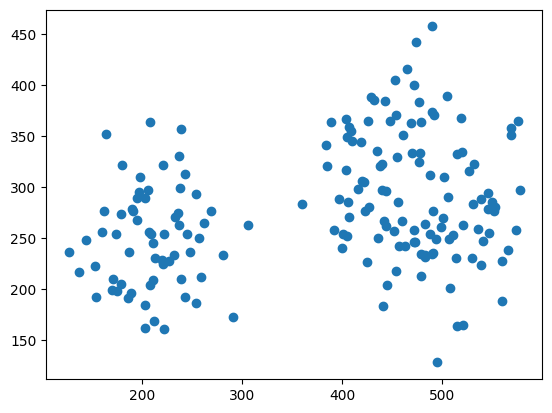

In [189]:
plt.scatter(df_2_cat["coord_x"], df_2_cat["coord_y"])

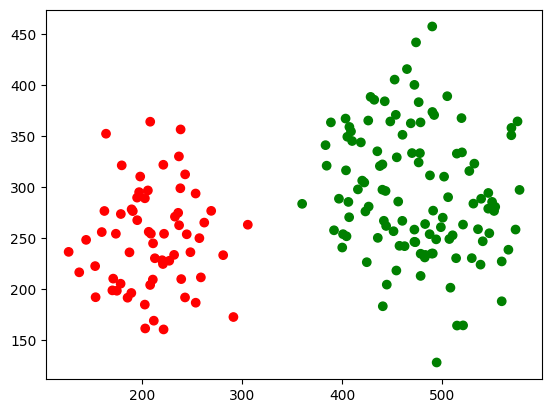

In [190]:
plt.scatter(df_2_cat["coord_x"], df_2_cat["coord_y"], c=df_2_cat["category"].map({"a":"red", "b":"green"}))

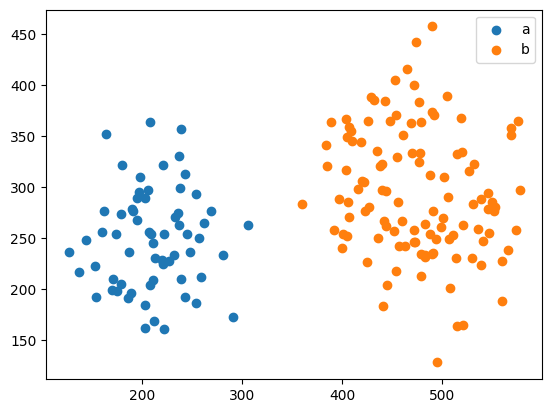

In [191]:
plt.scatter(df_2_cat[df_2_cat["category"] == "a"]["coord_x"], df_2_cat[df_2_cat["category"] == "a"]["coord_y"])
plt.scatter(df_2_cat[df_2_cat["category"] == "b"]["coord_x"], df_2_cat[df_2_cat["category"] == "b"]["coord_y"])
plt.legend(["a", "b"])

In [192]:
df_4_cat = pd.read_csv("datasets/4_categories.csv")
df_4_cat

,coord_x,coord_y,category
0,124.703038,350.089618,a
1,127.948668,417.534316,a
2,80.817806,395.823458,a
3,126.107518,383.713659,a
4,121.863843,355.151238,a
...,...,...,...
913,597.447179,80.049176,d
914,552.212837,77.267115,d
915,582.085716,58.248150,d
916,581.338270,55.497262,d


In [193]:
df_4_cat["category"].unique()

array(['a', 'b', 'c', 'd'], dtype=object)

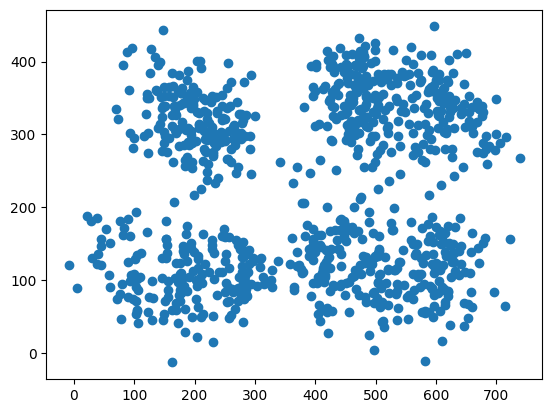

In [194]:
plt.scatter(df_4_cat["coord_x"], df_4_cat["coord_y"])

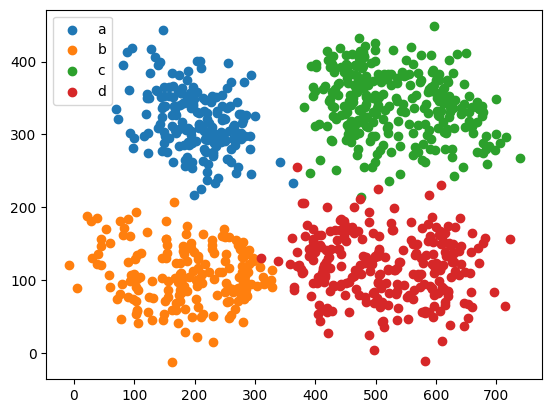

In [195]:
CATEGORIES = df_4_cat["category"].unique()

for cat in CATEGORIES:
    plt.scatter(df_4_cat[df_4_cat["category"] == cat]["coord_x"], df_4_cat[df_4_cat["category"] == cat]["coord_y"])

plt.legend(CATEGORIES)

In [196]:
def plot_data(df):
    categories = df["category"].unique() 
    for cat in categories:
        plt.scatter(df[df["category"] == cat]["coord_x"], df[df["category"] == cat]["coord_y"])
    plt.legend(categories)

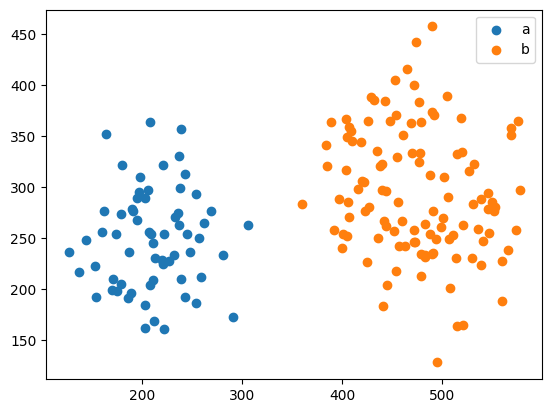

In [197]:
plot_data(df_2_cat)

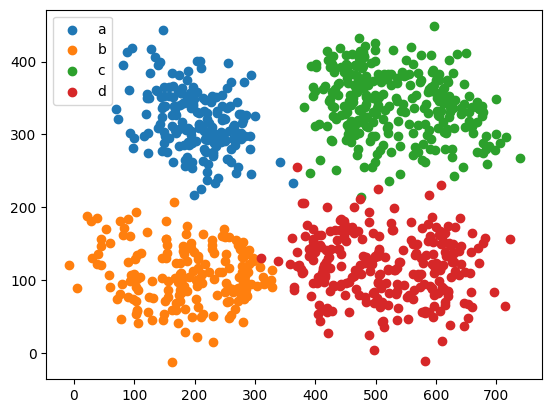

In [198]:
plot_data(df_4_cat)

In [199]:
from sklearn.tree import DecisionTreeClassifier

In [200]:
tree_model_2_cat = DecisionTreeClassifier()
tree_model_2_cat

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [201]:
df_2_cat.head(2)

,coord_x,coord_y,category
0,203.175900,185.107149,a
1,178.999121,205.587416,a


In [202]:
x = df_2_cat[["coord_x", "coord_y"]]
y = df_2_cat["category"]

In [203]:
tree_model_2_cat.fit(x, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


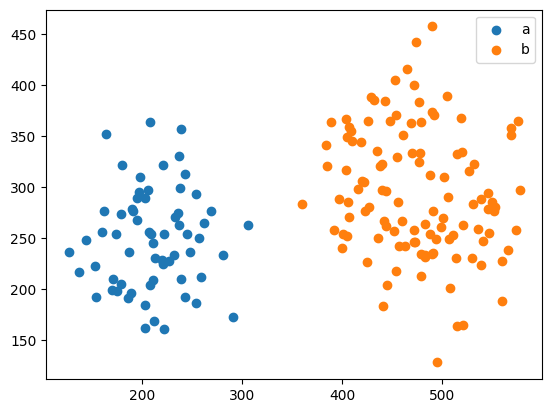

In [204]:
plot_data(df_2_cat)

In [205]:
tree_model_2_cat.predict([ [200, 150] ])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['a'], dtype=object)

In [206]:
tree_model_2_cat.predict([ [500, 350] ])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['b'], dtype=object)

In [207]:
tree_model_2_cat.predict([ [300, 350] ])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['a'], dtype=object)

# pip install graphiz

In [208]:
import  graphviz
from sklearn.tree import export_graphviz

In [209]:
y.unique()

array(['a', 'b'], dtype=object)

In [210]:
export_graphviz(tree_model_2_cat, feature_names = ["coord_x", "coord_y"], class_names=["a", "b"])

'digraph Tree {\nnode [shape=box, fontname="helvetica"] ;\nedge [fontname="helvetica"] ;\n0 [label="coord_x <= 333.067\\ngini = 0.46\\nsamples = 176\\nvalue = [63, 113]\\nclass = b"] ;\n1 [label="gini = 0.0\\nsamples = 63\\nvalue = [63, 0]\\nclass = a"] ;\n0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;\n2 [label="gini = 0.0\\nsamples = 113\\nvalue = [0, 113]\\nclass = b"] ;\n0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="False"] ;\n}'

In [211]:
exported_data = export_graphviz(tree_model_2_cat, feature_names = x.keys(), class_names=y.unique())
exported_data

'digraph Tree {\nnode [shape=box, fontname="helvetica"] ;\nedge [fontname="helvetica"] ;\n0 [label="coord_x <= 333.067\\ngini = 0.46\\nsamples = 176\\nvalue = [63, 113]\\nclass = b"] ;\n1 [label="gini = 0.0\\nsamples = 63\\nvalue = [63, 0]\\nclass = a"] ;\n0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;\n2 [label="gini = 0.0\\nsamples = 113\\nvalue = [0, 113]\\nclass = b"] ;\n0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="False"] ;\n}'

In [212]:
tree_graph = graphviz.Source(exported_data)
tree_graph.render("output/2_categories", format="png")

'output/2_categories.png'

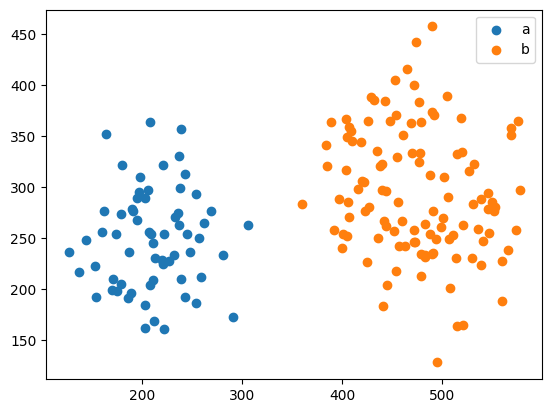

In [213]:
plot_data(df_2_cat)

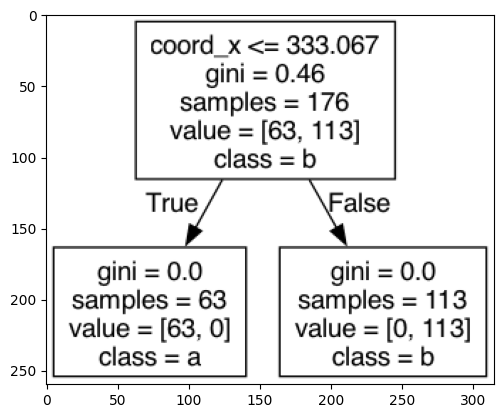

In [214]:
plt.imshow(plt.imread("output/2_categories.png"));

In [215]:
ELEMENTS = 400
linie_coord_x = np.ones(ELEMENTS) * 333.067
linie_coord_y = np.arange(100, 100 + ELEMENTS) 

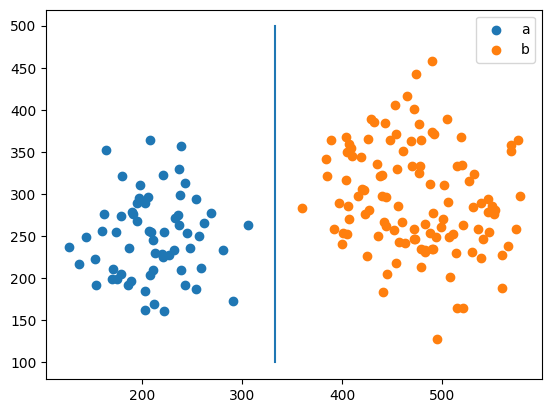

In [216]:
plot_data(df_2_cat)
plt.plot(linie_coord_x, linie_coord_y)

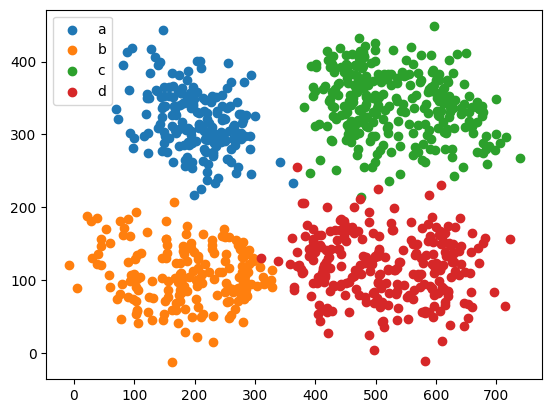

In [217]:
plot_data(df_4_cat)

In [218]:
x = df_4_cat[["coord_x", "coord_y"]]
y = df_4_cat["category"]

In [219]:
tree_model_4_cat = DecisionTreeClassifier()
tree_model_4_cat.fit(x, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [220]:
exported_data = export_graphviz(tree_model_4_cat, feature_names = x.keys(), class_names=y.unique())
tree_graph = graphviz.Source(exported_data)
tree_graph.render("output/4_categories", format="png")

'output/4_categories.png'

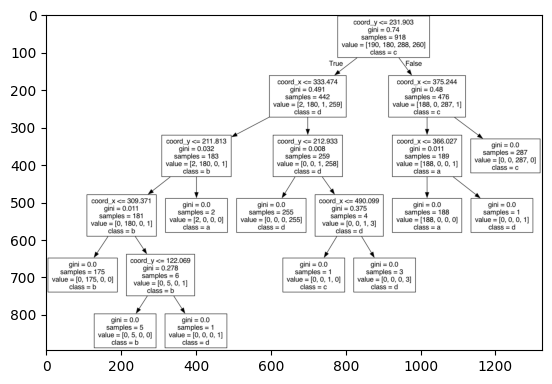

In [221]:
plt.imshow(plt.imread("output/4_categories.png"));

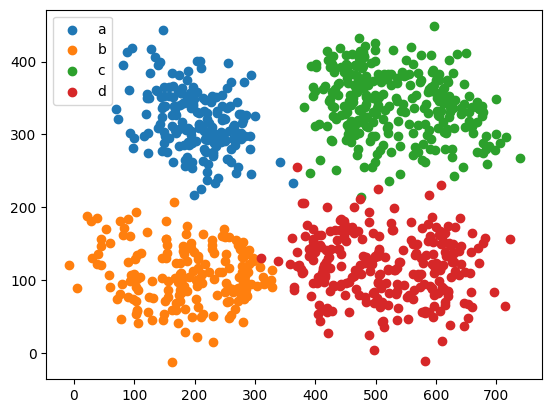

In [222]:
plot_data(df_4_cat)

In [223]:
ELEMENTS = 800

VALUE = 231.903

START_VALUE = 0

prima_linie_coord_x =   np.arange(START_VALUE, START_VALUE + ELEMENTS)  
prima_linie_coord_y =   np.ones(ELEMENTS) * VALUE

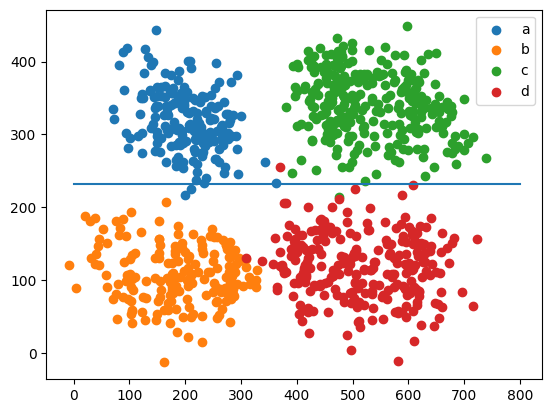

In [224]:
plot_data(df_4_cat)
plt.plot(prima_linie_coord_x, prima_linie_coord_y)

In [225]:
ELEMENTS = int(800 - 231.903) 
ELEMENTS

568

In [226]:
ELEMENTS = int(231.903) 

VALUE = 333.474

START_VALUE = 0

a_doua_linie_coord_x =   np.ones(ELEMENTS) * VALUE 
a_doua_linie_coord_y =  np.arange(START_VALUE, START_VALUE + ELEMENTS)  

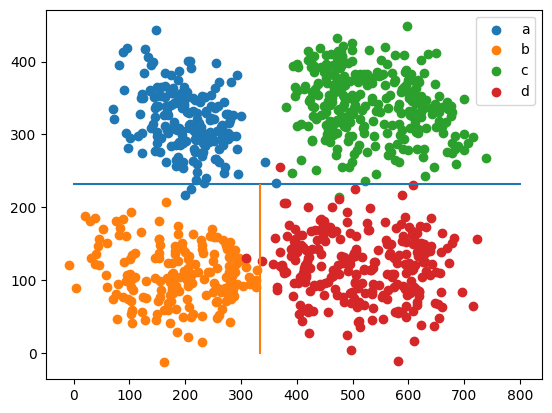

In [227]:
plot_data(df_4_cat)
plt.plot(prima_linie_coord_x, prima_linie_coord_y)
plt.plot(a_doua_linie_coord_x, a_doua_linie_coord_y)

In [228]:
ELEMENTS = int(500 - 231.903) 

VALUE = 375.244

START_VALUE = 231

a_treia_linie_coord_x =   np.ones(ELEMENTS) * VALUE 
a_treia_linie_coord_y =  np.arange(START_VALUE, START_VALUE + ELEMENTS)  

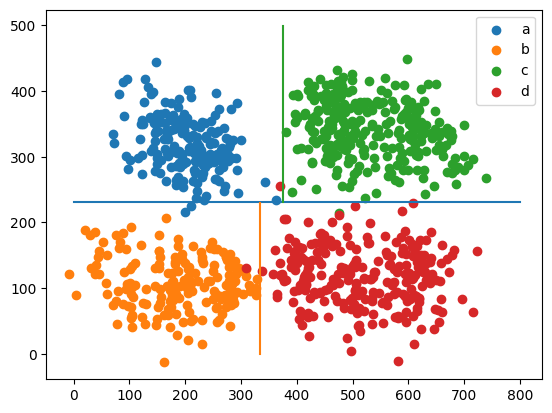

In [229]:
plot_data(df_4_cat)
plt.plot(prima_linie_coord_x, prima_linie_coord_y)
plt.plot(a_doua_linie_coord_x, a_doua_linie_coord_y)
plt.plot(a_treia_linie_coord_x, a_treia_linie_coord_y)